# Credit Card Fraud Detection

### Objective
Build an end-to-end machine learning pipeline to identify fraudulent financial transactions in a heavily imbalanced dataset, with special attention to **recall, precision, F1-score, and ROC-AUC** rather than accuracy alone.

### Dataset
This project uses the supplied `credit_card_fraud_10k.csv` file containing 10,000 transactions and the target column `is_fraud`.




In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

DATA_PATH = "credit_card_fraud_10k.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


## 1. Data quality and class imbalance

Data types:


,dtype
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,object
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64
is_fraud,int64



Missing values:


,missing
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


Legitimate transactions: 9,849
Fraudulent transactions: 151
Fraud percentage: 1.51%


,class,count,percentage
0,Legitimate,9849,98.49
1,Fraud,151,1.51


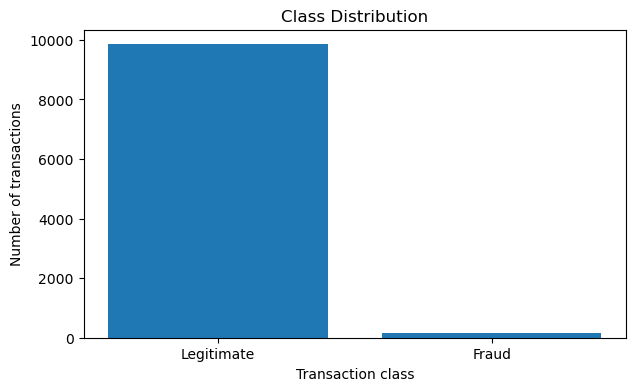

In [7]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

fraud_counts = df["is_fraud"].value_counts().sort_index()
fraud_pct = df["is_fraud"].mean() * 100

print(f"Legitimate transactions: {fraud_counts.get(0, 0):,}")
print(f"Fraudulent transactions: {fraud_counts.get(1, 0):,}")
print(f"Fraud percentage: {fraud_pct:.2f}%")

imbalance_table = pd.DataFrame({
    "class": ["Legitimate", "Fraud"],
    "count": [fraud_counts.get(0, 0), fraud_counts.get(1, 0)],
    "percentage": [
        fraud_counts.get(0, 0) / len(df) * 100,
        fraud_counts.get(1, 0) / len(df) * 100
    ]
})
display(imbalance_table)

plt.figure(figsize=(7, 4))
plt.bar(["Legitimate", "Fraud"], [fraud_counts.get(0, 0), fraud_counts.get(1, 0)])
plt.title("Class Distribution")
plt.xlabel("Transaction class")
plt.ylabel("Number of transactions")
plt.show()


## 2. Exploratory Data Analysis — transaction amount

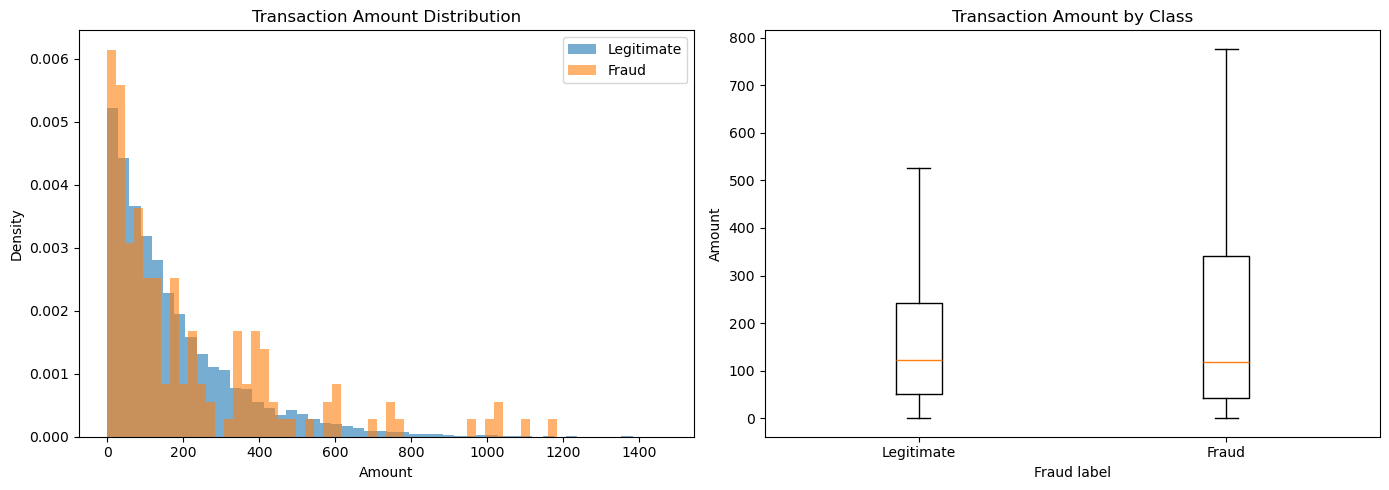

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,9849.0,175.33,173.99,0.00,50.99,122.11,241.65,1471.04
1,151.0,216.18,248.12,0.11,41.53,118.94,341.70,1185.07


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, name in [(0, "Legitimate"), (1, "Fraud")]:
    values = df.loc[df["is_fraud"] == label, "amount"]
    axes[0].hist(values, bins=50, density=True, alpha=0.6, label=name)
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].boxplot(
    [df.loc[df["is_fraud"] == 0, "amount"],
     df.loc[df["is_fraud"] == 1, "amount"]],
    labels=["Legitimate", "Fraud"],
    showfliers=False
)
axes[1].set_title("Transaction Amount by Class")
axes[1].set_xlabel("Fraud label")
axes[1].set_ylabel("Amount")

plt.tight_layout()
plt.show()

display(df.groupby("is_fraud")["amount"].describe().round(2))


## 3. Exploratory Data Analysis — time of day

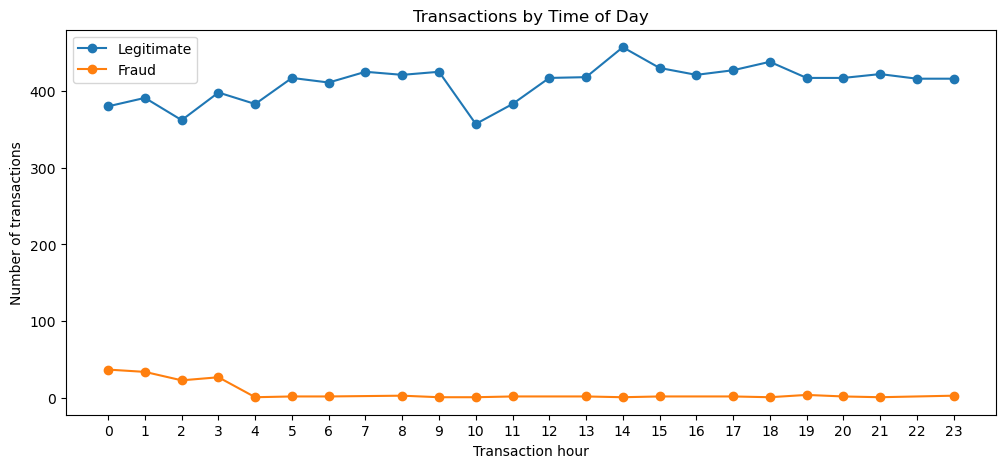

,fraud_count,transaction_count,fraud_rate_pct
transaction_hour,,,
0,37,417,8.87
1,34,425,8.00
2,23,385,5.97
3,27,425,6.35
4,1,384,0.26
5,2,419,0.48
6,2,413,0.48
7,0,425,0.00
8,3,424,0.71


In [9]:
hourly = (
    df.groupby(["transaction_hour", "is_fraud"])
      .size()
      .reset_index(name="transactions")
)

plt.figure(figsize=(12, 5))
for label, name in [(0, "Legitimate"), (1, "Fraud")]:
    part = hourly[hourly["is_fraud"] == label]
    plt.plot(part["transaction_hour"], part["transactions"], marker="o", label=name)
plt.title("Transactions by Time of Day")
plt.xlabel("Transaction hour")
plt.ylabel("Number of transactions")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

fraud_by_hour = df.groupby("transaction_hour")["is_fraud"].agg(
    fraud_count="sum", transaction_count="count", fraud_rate="mean"
)
fraud_by_hour["fraud_rate_pct"] = fraud_by_hour["fraud_rate"] * 100

display(fraud_by_hour[["fraud_count", "transaction_count", "fraud_rate_pct"]].round(2))


## Why accuracy is misleading for fraud detection

Fraud datasets are usually dominated by legitimate transactions. If only 1.5% of transactions are fraudulent, a model that predicts **every transaction as legitimate** can still achieve about 98.5% accuracy while detecting **zero fraud cases**.

For this reason, accuracy does not tell us whether the model is actually useful for fraud prevention.

- **Recall (sensitivity):** Of all real fraud cases, how many did we catch? High recall reduces missed fraud.
- **Precision:** Of all transactions flagged as fraud, how many were actually fraud? High precision reduces false alarms and unnecessary investigation/customer friction.
- **F1-score:** Harmonic mean of precision and recall; useful when both matter.
- **ROC-AUC:** Measures how well the model ranks fraud above legitimate transactions across thresholds.

In a fraud system, **recall is often the first priority because missing a fraudulent transaction can be costly**, but it should not be maximized blindly. Extremely high recall can create too many false positives. The practical operating point should therefore be chosen using the business cost of false negatives versus false positives.


In [10]:
print("A simple all-legitimate classifier would have accuracy:",
      f"{(df['is_fraud'].eq(0).mean()*100):.2f}%")
print("But its fraud recall would be 0.00 because it detects no fraud.")


A simple all-legitimate classifier would have accuracy: 98.49%
But its fraud recall would be 0.00 because it detects no fraud.


## Modeling choice and leakage prevention

The dataset contains both numerical and categorical variables. Categorical variables are one-hot encoded and numerical variables are standardized for Logistic Regression.

**Important:** SMOTE is applied **after the train/test split and inside an `imblearn` pipeline**. Therefore, synthetic observations are generated only from training data. The untouched test set represents the original class distribution and gives a more realistic evaluation.

A stratified split is used so that both training and test sets contain fraud cases in approximately the same proportion.


In [11]:
# Drop transaction_id: it is an identifier, not a meaningful predictive feature.
X = df.drop(columns=["is_fraud", "transaction_id"])
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print(f"Training fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate: {y_test.mean()*100:.2f}%")


Training set: (8000, 8)
Test set: (2000, 8)
Training fraud rate: 1.51%
Test fraud rate: 1.50%


In [12]:
categorical_features = ["merchant_category"]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

logistic_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

rf_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Both models trained successfully with SMOTE applied to training data.")


Both models trained successfully with SMOTE applied to training data.


## 4. Model evaluation

In [13]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model
}

results = []
roc_data = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)

    print(f"\n{name}")
    print(classification_report(
        y_test, y_pred,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    ))

results_df = pd.DataFrame(results).set_index("Model").round(4)
display(results_df)



Logistic Regression
              precision    recall  f1-score   support

  Legitimate     0.9995    0.9635    0.9811      1970
       Fraud     0.2871    0.9667    0.4427        30

    accuracy                         0.9635      2000
   macro avg     0.6433    0.9651    0.7119      2000
weighted avg     0.9888    0.9635    0.9731      2000


Random Forest
              precision    recall  f1-score   support

  Legitimate     0.9949    1.0000    0.9975      1970
       Fraud     1.0000    0.6667    0.8000        30

    accuracy                         0.9950      2000
   macro avg     0.9975    0.8333    0.8987      2000
weighted avg     0.9950    0.9950    0.9945      2000



,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.2871,0.9667,0.4427,0.9933
Random Forest,1.0000,0.6667,0.8000,0.9992


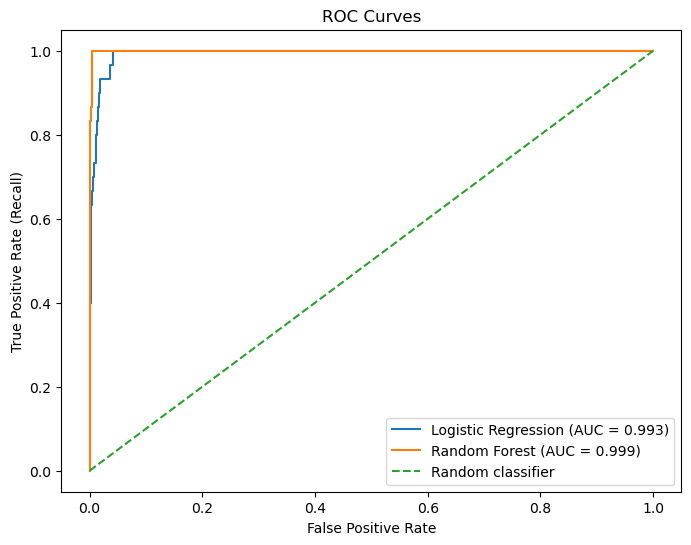

In [14]:
plt.figure(figsize=(8, 6))

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.show()


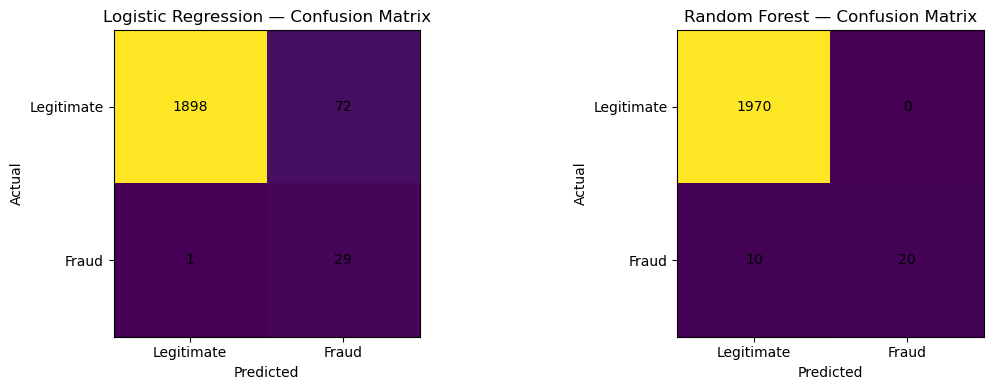

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm)
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["Legitimate", "Fraud"])
    ax.set_yticks([0, 1], ["Legitimate", "Fraud"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


## 5. Which metric matters most?

For a fraud-detection system, **Recall is usually the most important starting metric** because false negatives represent fraudulent transactions that pass through the system undetected.

However, maximizing recall alone is not enough. If the model flags almost every transaction as fraud, recall can be high while precision becomes unusably low. This creates customer friction and overwhelms fraud investigators.

Therefore, the preferred production approach is to:
1. prioritize a sufficiently high recall,
2. maintain an acceptable precision,
3. compare F1-score and ROC-AUC,
4. choose the final classification threshold using actual business costs.

The default 0.50 threshold is a modeling convention, not a business requirement.


,Threshold,Precision,Recall,F1
0,0.10,0.248,1.000,0.397
1,0.15,0.349,1.000,0.517
2,0.20,0.448,1.000,0.619
3,0.25,0.625,1.000,0.769
4,0.30,0.732,1.000,0.845
5,0.35,0.771,0.900,0.831
6,0.40,0.926,0.833,0.877
7,0.45,0.952,0.667,0.784
8,0.50,1.000,0.667,0.800
9,0.55,1.000,0.600,0.750


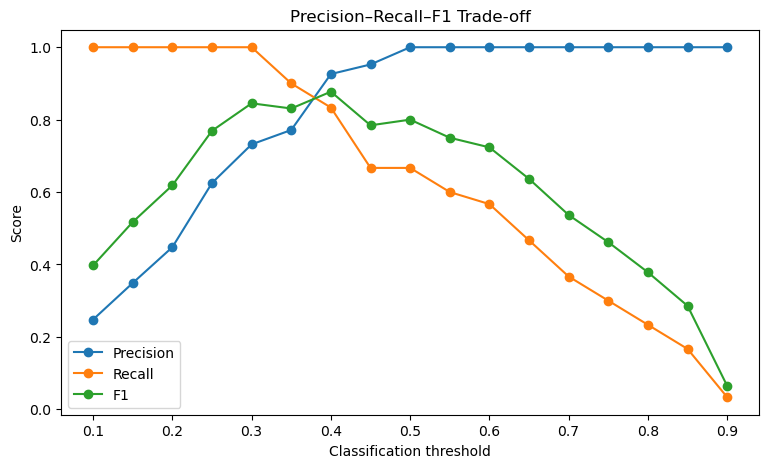

In [16]:
# Optional threshold analysis for the Random Forest
rf_prob = rf_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)
threshold_rows = []

for threshold in thresholds:
    pred = (rf_prob >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(3))

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision–Recall–F1 Trade-off")
plt.legend()
plt.show()


## 6. Feature importance / coefficient analysis

Top Logistic Regression coefficients by absolute magnitude:


,feature,coefficient
4,num__device_trust_score,-4.1018
1,num__transaction_hour,-3.4316
5,num__velocity_last_24h,2.6164
3,num__location_mismatch,2.2387
2,num__foreign_transaction,2.2061
0,num__amount,1.1943
6,num__cardholder_age,-0.9086
7,cat__merchant_category_Clothing,-0.7661
9,cat__merchant_category_Food,0.3324
10,cat__merchant_category_Grocery,0.3080


Top Random Forest features:


,feature,importance
1,num__transaction_hour,0.2627
4,num__device_trust_score,0.2208
2,num__foreign_transaction,0.1374
5,num__velocity_last_24h,0.1339
3,num__location_mismatch,0.1186
0,num__amount,0.0239
8,cat__merchant_category_Electronics,0.0238
10,cat__merchant_category_Grocery,0.0190
6,num__cardholder_age,0.0166
11,cat__merchant_category_Travel,0.0159


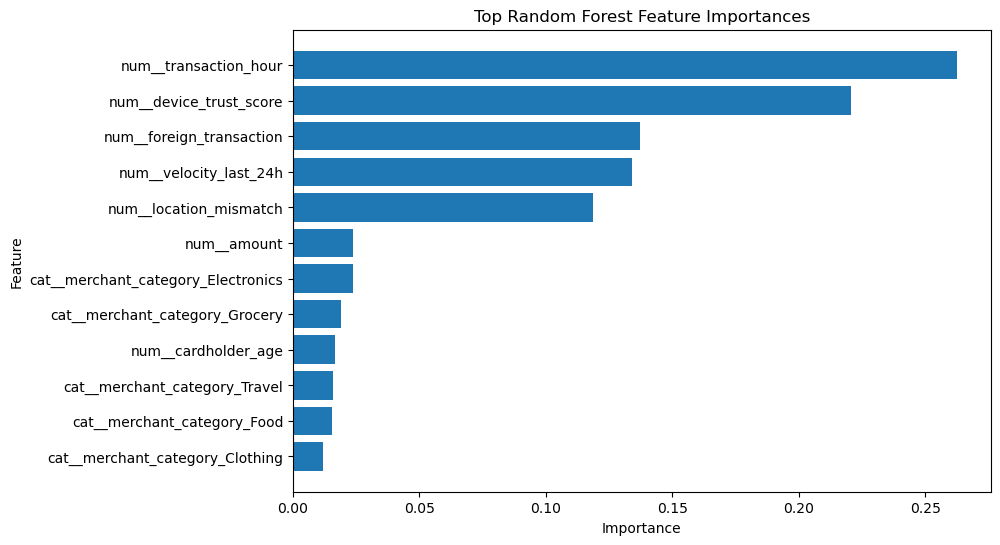

In [17]:
# Extract transformed feature names
feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
logit_coef = logistic_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logit_coef,
    "abs_coefficient": np.abs(logit_coef)
}).sort_values("abs_coefficient", ascending=False)

print("Top Logistic Regression coefficients by absolute magnitude:")
display(coef_df.head(15).drop(columns="abs_coefficient").round(4))

rf_importance = rf_model.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importance
}).sort_values("importance", ascending=False)

print("Top Random Forest features:")
display(importance_df.head(15).round(4))

plt.figure(figsize=(9, 6))
top_imp = importance_df.head(12).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Scalability: 1 million transactions per hour

One million transactions/hour is about **278 transactions/second** on average.

A production architecture could:
- Keep feature preprocessing identical between training and inference.
- Serve the trained model behind a low-latency API or streaming consumer.
- Use Kafka/Kinesis/Pub/Sub-style ingestion for continuous transaction streams.
- Precompute velocity, device-trust and behavioral features where possible.
- Batch predictions when latency requirements allow it.
- Use a lightweight model such as Logistic Regression for very low-latency screening, with a tree ensemble as a second-stage risk model.
- Monitor fraud prevalence, precision/recall, score drift and data-quality drift.
- Retrain periodically using newly labeled transactions.
- Keep SMOTE as a **training-time technique only**; never generate synthetic transactions in production.
- For very high throughput, horizontally scale stateless inference workers and use model serialization (for example, joblib) with versioning.

The benchmark dataset is only 10,000 rows, so production scalability cannot be proven from this dataset alone. The notebook demonstrates the modeling pipeline; load testing would be required before deployment.


## 7. Conclusion

This project demonstrates an imbalanced fraud-classification workflow using the supplied transaction dataset.

**Key takeaways**
- Fraud is a small minority class, so accuracy alone is misleading.
- Stratification ensures fraud appears in both training and test sets.
- SMOTE is used only on training data to reduce the impact of class imbalance without contaminating the test set.
- Logistic Regression provides a simple, interpretable baseline.
- Random Forest captures nonlinear relationships and provides feature-importance estimates.
- Precision, Recall, F1-score and ROC-AUC provide a more useful view of fraud-model performance.
- The final production threshold should be selected according to the financial cost of false negatives and false positives.


